# RNN con Anchoring + Unrolled Training

Combina dos enfoques complementarios:
- **`rnn03_unroll`** → rollout de W pasos (BPTT) para estabilizar el auto-feedback
- **`verificacion_anchoring_normfix`** → posición de reposo (frame 0) como referencia fija, eliminando deriva acumulada

```
Input por vértice: [x_anc, y_anc, z_anc,  ← anchor fijo (frame 0, NUNCA cambia)
                    x_t,   y_t,   z_t,    ← posición actual (o predicha en rollout)
                    sdf_t]                 ← distancia al objeto
Total: 7 features por vértice
```

## 1. Carga de datos

In [7]:
import pandas as pd
import numpy as np
import torch
import json
import os
from torch.utils.data import Dataset, DataLoader

csv_path = 'data/clothDataset_36_.csv'
df = pd.read_csv(csv_path)

num_vertices = 6
num_features_raw = 4  # x, y, z, sdf  (antes de añadir anchor)

selected_columns = []
for i in range(num_vertices):
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])

df_filtered = df[selected_columns]
data_flat   = df_filtered.values
num_frames  = data_flat.shape[0]

data_3d     = data_flat.reshape((num_frames, num_vertices, num_features_raw))
data_tensor = torch.tensor(data_3d, dtype=torch.float32)

print(f"Frames totales: {num_frames}")
print(f"Tensor shape:   {data_tensor.shape}  # [Frames, Vertices, 4(x,y,z,sdf)]")

Frames totales: 1000
Tensor shape:   torch.Size([1000, 6, 4])  # [Frames, Vertices, 4(x,y,z,sdf)]


## 2. Dataset con Anchoring + ventana de rollout

**Diferencias respecto a los notebooks anteriores:**
- Como `rnn03_unroll`: cada ítem devuelve `seq_len` frames de historia + `rollout_steps` frames futuros
- Como `verificacion_anchoring`: cada frame de la historia lleva concatenado el anchor (frame 0)
- **Nuevo**: el anchor se inyecta en canales 0-2; durante el rollout estos canales nunca se sobreescriben

In [8]:
class ClothAnchoredUnrolledDataset(Dataset):
    """
    Devuelve:
      - sequence:      [seq_len, V, 7]   <- historia con anchor inyectado
                                            canales: [anc_xyz | pos_t_xyz | sdf_t]
      - future_frames: [rollout, V, 4]   <- frames futuros reales (x,y,z,sdf)

    El anchor (posiciones XYZ del frame 0) es idéntico en todos los pasos
    de la secuencia y permanece fijo durante el rollout de inferencia.
    """
    def __init__(self, data_tensor, seq_len=5, rollout_steps=8):
        # data_tensor: [Frames, V, 4]  (x, y, z, sdf)
        if not isinstance(data_tensor, torch.Tensor):
            self.data = torch.tensor(data_tensor, dtype=torch.float32)
        else:
            self.data = data_tensor
        self.seq_len       = seq_len
        self.rollout_steps = rollout_steps
        # Ancla fija: posiciones XYZ del primer frame  →  [V, 3]
        self.anchor = self.data[0, :, 0:3]

    def __len__(self):
        return len(self.data) - self.seq_len - self.rollout_steps

    def _inject_anchor(self, frames):
        """
        frames: [T, V, 4]  →  [T, V, 7]
        Concatena anchor (canal 0-2) delante de cada frame.
        """
        T, V, _ = frames.shape
        anc = self.anchor.unsqueeze(0).expand(T, -1, -1)  # [T, V, 3]
        return torch.cat([anc, frames], dim=-1)            # [T, V, 7]

    def __getitem__(self, idx):
        seq = self.data[idx : idx + self.seq_len]                              # [seq_len, V, 4]
        fut = self.data[idx+self.seq_len : idx+self.seq_len+self.rollout_steps] # [rollout, V, 4]
        return self._inject_anchor(seq), fut  # ([seq_len,V,7], [rollout,V,4])


SEQ_LEN       = 5
ROLLOUT_STEPS = 8
BATCH_SIZE    = 32

dataset = ClothAnchoredUnrolledDataset(data_tensor, seq_len=SEQ_LEN, rollout_steps=ROLLOUT_STEPS)

# Split cronológico
train_size    = int(0.8 * len(dataset))
train_dataset = torch.utils.data.Subset(dataset, range(train_size))
test_dataset  = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Verificar shapes
seq_b, fut_b = next(iter(train_loader))
print(f"sequence shape:      {seq_b.shape}   # [B, seq_len, V, 7]")
print(f"future_frames shape: {fut_b.shape}   # [B, rollout, V, 4]")
print(f"Anchor (canal 0-2 del primer frame): {seq_b[0, 0, 0, 0:3]}")
print(f"Anchor (canal 0-2 del último frame): {seq_b[0, -1, 0, 0:3]}  ← debe ser igual")

sequence shape:      torch.Size([32, 5, 6, 7])   # [B, seq_len, V, 7]
future_frames shape: torch.Size([32, 8, 6, 4])   # [B, rollout, V, 4]
Anchor (canal 0-2 del primer frame): tensor([ 0.0000,  0.0000, -0.2255])
Anchor (canal 0-2 del último frame): tensor([ 0.0000,  0.0000, -0.2255])  ← debe ser igual


## 3. Estadísticas de normalización

**Fix crítico heredado de `verificacion_anchoring_normfix`:**  
Los canales 0-2 (anchor) tienen `std ≈ 0` porque son constantes → se fuerza `mean=0, std=1`  
para evitar divisiones por casi-cero que producirían magnitudes enormes en inferencia.

In [9]:
NUM_FEATURES_IN = 7  # 3 anchor + 3 pos_t + 1 sdf

all_inputs  = []
all_targets = []

for batch_seq, batch_future in train_loader:
    # batch_seq: [B, seq_len, V, 7]
    all_inputs.append(batch_seq.view(-1, NUM_FEATURES_IN))

    # Delta del primer frame futuro respecto a la posición actual (canal 3:6)
    last_pos         = batch_seq[:, -1, :, 3:6]    # posición actual → canales 3-5
    first_future_pos = batch_future[:, 0, :, 0:3]
    delta = first_future_pos - last_pos
    all_targets.append(delta.view(-1, 3))

full_input  = torch.cat(all_inputs,  dim=0)
full_target = torch.cat(all_targets, dim=0)

input_mean  = full_input.mean(dim=0)   # [7]
input_std   = full_input.std(dim=0)    # [7]
target_mean = full_target.mean(dim=0)  # [3]
target_std  = full_target.std(dim=0)   # [3]

# ── FIX ANCHOR ────────────────────────────────────────────────────────────────
# Canales 0-2 (anchor xyz): constantes → std≈0 → NO normalizar
input_mean[0:3] = 0.0
input_std[0:3]  = 1.0
# Canales dinámicos
input_std[3:]   = input_std[3:].clamp(min=1e-8)
target_std      = target_std.clamp(min=1e-8)

assert input_std[0].item() == 1.0, "ERROR: std anchor canal 0 no es 1.0"
print("✓ Canales anchor [0-2]: mean=0, std=1 (sin normalización estadística)")
print(f"  std canales dinámicos [3-6]: {input_std[3:].tolist()}")
print(f"  target_mean: {target_mean.tolist()}")
print(f"  target_std:  {target_std.tolist()}")

norm_data = {
    "mean":        input_mean.tolist(),
    "std":         input_std.tolist(),
    "target_mean": target_mean.tolist(),
    "target_std":  target_std.tolist()
}
with open("cloth_norm_params_anchored_unrolled.json", "w") as f:
    json.dump(norm_data, f)
print("Norm params guardados en cloth_norm_params_anchored_unrolled.json")

✓ Canales anchor [0-2]: mean=0, std=1 (sin normalización estadística)
  std canales dinámicos [3-6]: [0.2537499964237213, 0.3668252229690552, 0.22461259365081787, 0.5491922497749329]
  target_mean: [0.00030948585481382906, 8.435206837020814e-05, 1.2861080449511064e-06]
  target_std:  [0.0830022543668747, 0.028461886569857597, 0.00868280977010727]
Norm params guardados en cloth_norm_params_anchored_unrolled.json


## 4. Modelo

La arquitectura RNN es idéntica a `rnn03_unroll`. Solo cambia `num_features` de 4 → 7.  
La red nunca "sabe" explícitamente que los canales 0-2 son el anchor; aprende por sí sola
a usar esa referencia estable para corregir deriva.

In [10]:
import torch.nn as nn

class FlatRNNClothUnity(nn.Module):
    def __init__(self, num_vertices, num_features, hidden_size, num_outputs=3):
        super().__init__()
        self.num_vertices = num_vertices
        self.num_outputs  = num_outputs
        self.input_size   = num_vertices * num_features
        self.hidden_size  = hidden_size

        self.rnn_cell = nn.RNNCell(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            nonlinearity='relu'
        )
        self.fc = nn.Linear(self.hidden_size, num_vertices * num_outputs)

    def forward(self, x):
        """
        x: [Batch, Seq_Len, Vertices, Features]
        returns pred_delta: [Batch, Vertices, 3]
        """
        B, T, V, F = x.shape
        x_flat = x.view(B, T, -1)                           # [B, T, V*F]
        h_t = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h_t = self.rnn_cell(x_flat[:, t, :], h_t)
        pred_flat  = self.fc(h_t)                           # [B, V*3]
        pred_delta = pred_flat.view(B, self.num_vertices, self.num_outputs)
        return pred_delta


HIDDEN_SIZE = 128
model = FlatRNNClothUnity(
    num_vertices=num_vertices,
    num_features=NUM_FEATURES_IN,  # 7  ←  única diferencia respecto a rnn03
    hidden_size=HIDDEN_SIZE,
    num_outputs=3
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total_params:,}")
print(f"Input size RNNCell: {model.input_size}  ({num_vertices} vértices × {NUM_FEATURES_IN} features)")

Parámetros totales: 24,338
Input size RNNCell: 42  (6 vértices × 7 features)


## 5. Unrolled Training Loop con Anchoring

### Lógica del rollout

```
for k in range(W):
    pred_delta = model(window_norm)          # predice Δ del siguiente frame
    pred_pos   = last_pos + denorm(delta)    # posición predicha

    loss += L1(pred_pos, real_pos_k) + L1(pred_vel, real_vel_k)

    # Construir nuevo frame:
    new_frame[:, :, 0:3] = anchor   # ← NUNCA CAMBIA (diferencia clave)
    new_frame[:, :, 3:6] = pred_pos # ← única parte que se actualiza
    new_frame[:, :, 6:7] = sdf_real # ← del frame futuro real

    window = roll(window, new_frame)
```

El gradiente se propaga hacia atrás a través de **toda la cadena** de predicciones (BPTT),
y el anchor permanece constante dando a la red una referencia estable incluso en rollouts largos.

In [16]:
criterion   = nn.L1Loss()
optimizer   = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler   = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

EPOCHS      = 300
NOISE_SIGMA = 0.02   # ruido SOLO en canales pos_t (3:6), nunca en el anchor
VEL_WEIGHT  = 1.0


# ── Helpers de normalización ───────────────────────────────────────────────────
def norm_input(x):
    """ x: [..., 7] """
    return (x - input_mean) / input_std

def denorm_delta(d):
    """ d: [..., 3] """
    return d * target_std + target_mean

def norm_delta(d):
    return (d - target_mean) / target_std


# ── Rollout combinado ──────────────────────────────────────────────────────────
def run_rollout(batch_seq, batch_future, add_noise=False):
    """
    batch_seq:    [B, seq_len, V, 7]  — historia con anchor inyectado
    batch_future: [B, rollout, V, 4]  — frames futuros reales (x,y,z,sdf)

    Canales de batch_seq:
      0:3 → anchor_xyz  (constante, NUNCA se sobreescribe)
      3:6 → pos_t_xyz   (se actualiza con cada predicción)
      6:7 → sdf_t       (se toma del frame futuro real)
    """
    B, W, V, _ = batch_future.shape
    window = batch_seq.clone()   # [B, seq_len, V, 7]

    # Ruido SOLO en canales de posición actual (3:6) — anchor intacto
    if add_noise:
        noise = torch.randn_like(window[:, -2:, :, 3:6]) * NOISE_SIGMA
        window[:, -2:, :, 3:6] = window[:, -2:, :, 3:6] + noise

    total_loss    = torch.tensor(0.0, device=batch_seq.device)
    prev_pred_pos = window[:, -1, :, 3:6]   # pos del frame t-1 (para vel)

    for k in range(W):
        # ── Forward ────────────────────────────────────────────────────────
        window_norm     = norm_input(window)       # normaliza los 7 canales
        pred_delta_norm = model(window_norm)        # [B, V, 3]

        last_pos         = window[:, -1, :, 3:6]   # pos_t actual (canales 3-5)
        pred_delta_real  = denorm_delta(pred_delta_norm)
        pred_pos         = last_pos + pred_delta_real   # posición predicha [B,V,3]

        # ── Targets reales ─────────────────────────────────────────────────
        real_pos  = batch_future[:, k, :, 0:3]
        real_prev = (
            batch_future[:, k-1, :, 0:3] if k > 0
            else batch_seq[:, -1, :, 3:6]   # pos del último frame de historia
        )

        # ── Loss posición ──────────────────────────────────────────────────
        real_delta      = real_pos - last_pos
        real_delta_norm = norm_delta(real_delta)
        loss_pos = criterion(pred_delta_norm, real_delta_norm)

        # ── Loss velocidad (Holden et al. §5.4) ────────────────────────────
        pred_vel = pred_pos - prev_pred_pos
        real_vel = real_pos - real_prev
        loss_vel = criterion(
            pred_vel / target_std.clamp(min=1e-8),
            real_vel / target_std.clamp(min=1e-8)
        )

        total_loss = total_loss + loss_pos + VEL_WEIGHT * loss_vel

        # ── Feedback: construir nuevo frame ────────────────────────────────
        new_frame = window[:, -1, :, :].clone()
        #   canales 0:3 (anchor) → NO SE TOCAN, ya tienen el valor correcto
        #   canal  3:6 (pos_t)   → se actualiza con la predicción
        new_frame[:, :, 3:6] = pred_pos.detach() if not model.training else pred_pos
        #   canal  6:7 (sdf)     → se toma del frame futuro real
        new_frame[:, :, 6:7] = batch_future[:, k, :, 3:4]

        # Desplazar ventana
        window = torch.cat([window[:, 1:, :, :], new_frame.unsqueeze(1)], dim=1)
        prev_pred_pos = pred_pos

    return total_loss / W

In [17]:
# ── Bucle de entrenamiento ─────────────────────────────────────────────────────
history = {'train': [], 'test': [], 'vertex_error': []}

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for batch_seq, batch_future in train_loader:
        batch_seq    = batch_seq.float()
        batch_future = batch_future.float()

        loss = run_rollout(batch_seq, batch_future, add_noise=True)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # ── TEST ─────────────────────────────────────────────────────────────────
    model.eval()
    test_loss   = 0.0
    total_err   = 0.0
    total_verts = 0

    all_pred_pos   = []
    all_target_pos = []

    with torch.no_grad():
        for batch_seq, batch_future in test_loader:
            batch_seq    = batch_seq.float()
            batch_future = batch_future.float()

            loss = run_rollout(batch_seq, batch_future, add_noise=False)
            test_loss += loss.item()

            # Métrica: error en el primer frame predicho
            window_norm = norm_input(batch_seq)
            pred_dn     = model(window_norm)
            last_pos    = batch_seq[:, -1, :, 3:6]   # canales 3-5 = pos_t
            pred_pos    = last_pos + denorm_delta(pred_dn)
            target_pos  = batch_future[:, 0, :, 0:3]

            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())

            distances    = torch.norm(pred_pos - target_pos, dim=-1)
            total_err   += distances.sum().item()
            total_verts += distances.numel()

    avg_test     = test_loss  / len(test_loader)
    avg_vert_err = total_err  / total_verts

    history['train'].append(avg_train)
    history['test'].append(avg_test)
    history['vertex_error'].append(avg_vert_err)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | Train: {avg_train:.6f} | Test: {avg_test:.6f} | Vertex Err: {avg_vert_err:.6f} m")

    # Error relativo cada 100 épocas
    if epoch % 50 == 0:
        preds_np   = np.concatenate(all_pred_pos,   axis=0)
        targets_np = np.concatenate(all_target_pos, axis=0)

        vertex_positions = data_tensor[:, :, 0:3]
        vertex_range = (
            (vertex_positions.max(dim=0).values - vertex_positions.min(dim=0).values)
            .mean(dim=-1)
        )  # [V]
        error_per_vertex  = np.linalg.norm(preds_np - targets_np, axis=-1).mean(axis=0)  # [V]
        relative_error    = error_per_vertex / vertex_range.numpy()

        print(f"  → Error relativo medio:  {relative_error.mean():.1%}")
        print(f"  → Error relativo máximo: {relative_error.max():.1%}  (vértice {relative_error.argmax()})")

Epoch    1 | Train: 1.482423 | Test: 0.894623 | Vertex Err: 0.021356 m
Epoch   10 | Train: 1.468663 | Test: 0.866594 | Vertex Err: 0.020684 m
Epoch   20 | Train: 1.429180 | Test: 0.834335 | Vertex Err: 0.019898 m
Epoch   30 | Train: 1.397867 | Test: 0.817520 | Vertex Err: 0.019317 m
Epoch   40 | Train: 1.379436 | Test: 0.787168 | Vertex Err: 0.018593 m
Epoch   50 | Train: 1.370947 | Test: 0.767466 | Vertex Err: 0.018105 m
  → Error relativo medio:  inf%
  → Error relativo máximo: inf%  (vértice 4)


C:\Users\mikel\AppData\Local\Temp\ipykernel_11832\3033515362.py:78: RuntimeWarning: divide by zero encountered in divide
  relative_error    = error_per_vertex / vertex_range.numpy()


Epoch   60 | Train: 1.342682 | Test: 0.752545 | Vertex Err: 0.017662 m
Epoch   70 | Train: 1.331594 | Test: 0.753895 | Vertex Err: 0.017232 m
Epoch   80 | Train: 1.325891 | Test: 0.738868 | Vertex Err: 0.016898 m
Epoch   90 | Train: 1.307839 | Test: 0.714935 | Vertex Err: 0.016564 m
Epoch  100 | Train: 1.302086 | Test: 0.705611 | Vertex Err: 0.016291 m
  → Error relativo medio:  inf%
  → Error relativo máximo: inf%  (vértice 4)
Epoch  110 | Train: 1.276422 | Test: 0.702376 | Vertex Err: 0.016160 m
Epoch  120 | Train: 1.280947 | Test: 0.690258 | Vertex Err: 0.015908 m
Epoch  130 | Train: 1.257584 | Test: 0.672426 | Vertex Err: 0.015526 m
Epoch  140 | Train: 1.259068 | Test: 0.674891 | Vertex Err: 0.015294 m
Epoch  150 | Train: 1.247142 | Test: 0.664648 | Vertex Err: 0.015194 m
  → Error relativo medio:  inf%
  → Error relativo máximo: inf%  (vértice 4)
Epoch  160 | Train: 1.251810 | Test: 0.658027 | Vertex Err: 0.015024 m
Epoch  170 | Train: 1.244243 | Test: 0.651628 | Vertex Err: 0.014

## 6. Visualización de curvas de loss

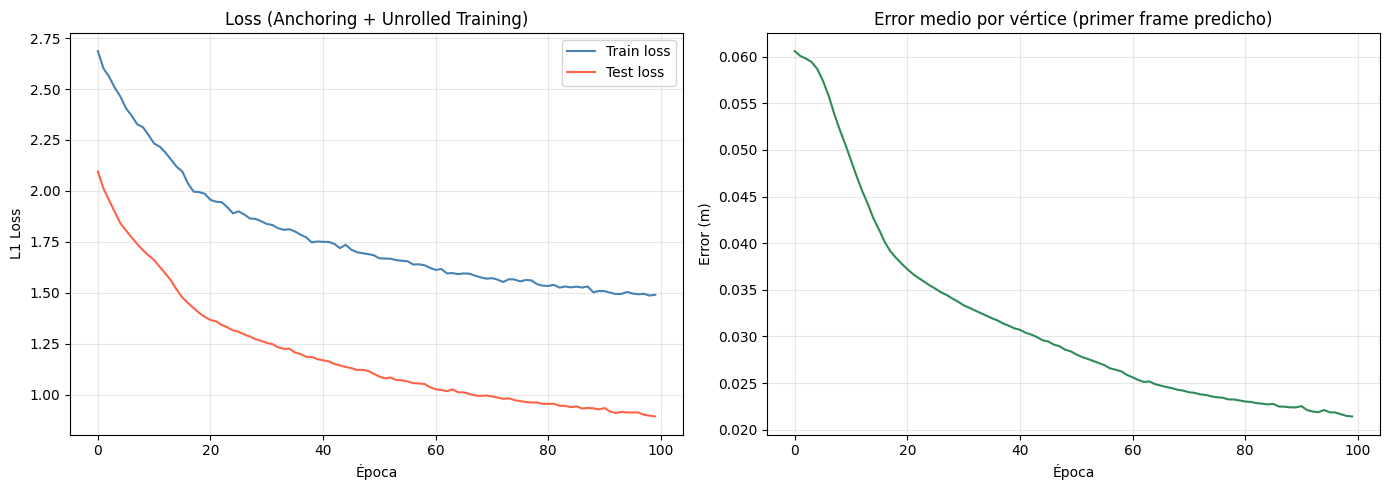

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train'], label='Train loss', color='steelblue')
ax1.plot(history['test'],  label='Test loss',  color='tomato')
ax1.set_title('Loss (Anchoring + Unrolled Training)')
ax1.set_xlabel('Época')
ax1.set_ylabel('L1 Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['vertex_error'], color='seagreen')
ax2.set_title('Error medio por vértice (primer frame predicho)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Error (m)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Visualización 3D — frame a elección

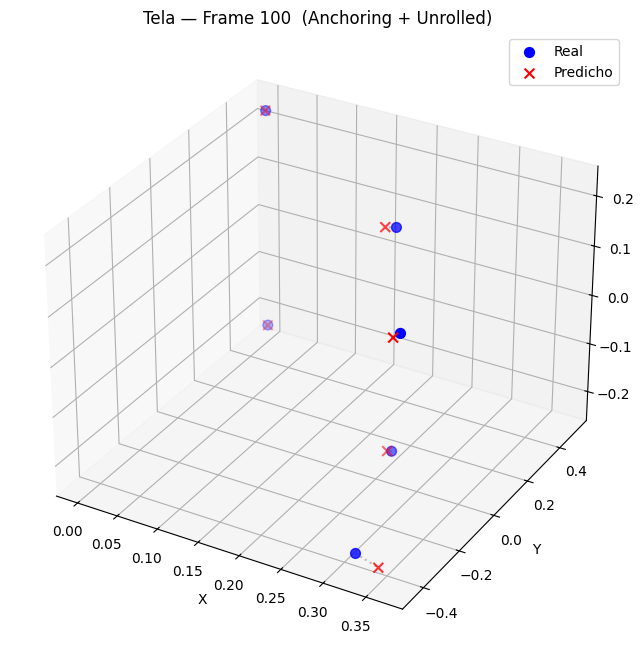

In [14]:
preds_np   = np.concatenate(all_pred_pos,   axis=0)  # [Frames_test, V, 3]
targets_np = np.concatenate(all_target_pos, axis=0)

frame_idx  = 100  # cambia para explorar distintos momentos

real_frame = targets_np[frame_idx]
pred_frame = preds_np[frame_idx]

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(*real_frame.T, c='blue', label='Real',     s=50, marker='o')
ax.scatter(*pred_frame.T, c='red',  label='Predicho', s=50, marker='x')

for i in range(real_frame.shape[0]):
    ax.plot(
        [real_frame[i,0], pred_frame[i,0]],
        [real_frame[i,1], pred_frame[i,1]],
        [real_frame[i,2], pred_frame[i,2]],
        color='gray', linestyle='dotted', alpha=0.5
    )

ax.set_title(f'Tela — Frame {frame_idx}  (Anchoring + Unrolled)')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend()
plt.show()

## 8. Guardado del modelo y export ONNX

El input ONNX cambia de `(B, seq_len, V, 4)` → `(B, seq_len, V, 7)`.  
En Unity, antes de invocar el modelo hay que concatenar el anchor (posición frame 0)
en los canales 0-2 de cada frame de la ventana histórica.

In [15]:
import torch
import onnx
import onnxruntime

# Guardar pesos PyTorch
torch.save(model.state_dict(), "cloth_anchored_unrolled.pth")
print("Modelo guardado en cloth_anchored_unrolled.pth")

# Export ONNX
model.eval()
# Input: (Batch=1, seq_len=5, Vertices=25, Features=7)
dummy_input = torch.randn(1, SEQ_LEN, num_vertices, NUM_FEATURES_IN)

torch.onnx.export(
    model,
    dummy_input,
    "cloth_anchored_unrolled.onnx",
    export_params=True,
    opset_version=9,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("Modelo exportado a cloth_anchored_unrolled.onnx")
print(f"Input shape ONNX: (batch, {SEQ_LEN}, {num_vertices}, {NUM_FEATURES_IN})")
print("Recuerda: en Unity los canales 0-2 de cada frame deben ser la posición del frame 0 (anchor fijo)")

# Verificar con onnxruntime
sess = onnxruntime.InferenceSession("cloth_anchored_unrolled.onnx")
out  = sess.run(None, {'input': dummy_input.numpy()})
print(f"Output shape ONNX verificado: {out[0].shape}  # [1, {num_vertices}, 3]")

Modelo guardado en cloth_anchored_unrolled.pth
Modelo exportado a cloth_anchored_unrolled.onnx
Input shape ONNX: (batch, 5, 6, 7)
Recuerda: en Unity los canales 0-2 de cada frame deben ser la posición del frame 0 (anchor fijo)
Output shape ONNX verificado: (1, 6, 3)  # [1, 6, 3]
